<a href="https://colab.research.google.com/github/Gnana-Prashanth/ML/blob/main/Covid19.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 # Problem Statement

 Given data about COVID-19 patients, write code to visualize the impact and
 analyze the trend of rate of infection and recovery as well as make predictions
 about the number of cases expected a week in future based on the current
 trends.

🧠 Introduction: Predicting COVID-19 Cases with Facebook Prophet
We all remember the COVID-19 pandemic — a time when the entire world was closely watching how the virus was spreading. Every day, news channels and websites showed live dashboards, rising case counts, and future projections for different countries. We heard things like:

“India may see a rise of 1 lakh cases by next week!”
“Experts predict a peak in infections by end of the month.”

These predictions were based on real data and statistical models.

📈 In this notebook, we’re going to do something very similar!
We will work with real-world COVID-19 data and use a powerful forecasting tool called Facebook Prophet to:

Understand trends in confirmed, recovered, and death cases.

Identify the top affected countries.

Predict how cases could grow in the future.

Visualize the uncertainty in predictions using confidence intervals.

🧪 Why Facebook Prophet?
Prophet is a time series forecasting model developed by Facebook that is:

Simple to use.

Works well with daily data that has seasonal trends (like COVID cases).

Gives us clear predictions with upper and lower bounds (like how the news said “cases may range from X to Y”).

📊 Through this analysis, you will see how data science can help us forecast, plan, and prepare during real-world crises like pandemics.

Let’s dive into the data and start predicting!

✅ Let me know if you’d like this broken into slides or sections.







You said:
i am asking you to talk about covu=id only make it ,ore intervactive earlier its good but not interactive


🧠 Introduction: Let’s Rewind to the COVID-19 Pandemic
Do you remember the time when COVID-19 hit the world?
It was all over the news — every single day.

🗓️ We used to wake up and check:

“How many cases today?”

“Is it safe to go outside?”

“Which countries are most affected?”

“When will this end?”

📺 News channels and websites were showing live case counts, death tolls, and sometimes even predictions about how many people could get infected next week or next month.

➡️ Ever wondered how those predictions were made?
That’s exactly what we’re going to explore in this notebook! 🔍

💡 What Are We Doing Here?
We will:

Use real COVID-19 data that was collected during the pandemic 📊

Identify the most affected countries 🌍

Use a powerful forecasting model called Facebook Prophet to predict future cases, just like experts did during the crisis! 📈

🔮 Why Facebook Prophet?
Prophet is a forecasting tool created by Facebook that:

Is easy to use (great for beginners!)

Works really well with daily data, like COVID-19 case numbers

Gives us a range of predictions — like:

"Cases might be around 1000 tomorrow, but could go as high as 1300 or stay as low as 700."

🤔 Why Does It Matter?
During a pandemic, governments and hospitals need to plan ahead:

How many beds will be needed?

Do we need more oxygen or vaccines?

Should we announce a lockdown?

 # Guidelines:
 ● Use pandas to accumulate data from multiple data files.

 ● Use plotly (visualization library) to create interactive visualizations.

 ● Use Facebook prophet library to make time series models.

 ● Visualize the prediction by combining these technologies

In [ ]:
# Data Set - https://drive.google.com/file/d/1sGg8J2oKMKOh_KGec3qr6RkroI8NhGIn/view?usp=sharing

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_csv('/content/Covid_19_Clean_Complete.csv')

In [ ]:
df

,Province/State,Country/Region,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
0,NaN,Afghanistan,33.939110,67.709953,2020-01-22,0,0,0,0,Eastern Mediterranean
1,NaN,Albania,41.153300,20.168300,2020-01-22,0,0,0,0,Europe
2,NaN,Algeria,28.033900,1.659600,2020-01-22,0,0,0,0,Africa
3,NaN,Andorra,42.506300,1.521800,2020-01-22,0,0,0,0,Europe
4,NaN,Angola,-11.202700,17.873900,2020-01-22,0,0,0,0,Africa
...,...,...,...,...,...,...,...,...,...,...
49063,NaN,Sao Tome and Principe,0.186400,6.613100,2020-07-27,865,14,734,117,Africa
49064,NaN,Yemen,15.552727,48.516388,2020-07-27,1691,483,833,375,Eastern Mediterranean
49065,NaN,Comoros,-11.645500,43.333300,2020-07-27,354,7,328,19,Africa
49066,NaN,Tajikistan,38.861000,71.276100,2020-07-27,7235,60,6028,1147,Europe


In [ ]:
#renaming column names for convenience
df.rename(columns={"Province/State":"State","Country/Region":"country"},inplace=True)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49068 entries, 0 to 49067
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   State       14664 non-null  object 
 1   country     49068 non-null  object 
 2   Lat         49068 non-null  float64
 3   Long        49068 non-null  float64
 4   Date        49068 non-null  object 
 5   Confirmed   49068 non-null  int64  
 6   Deaths      49068 non-null  int64  
 7   Recovered   49068 non-null  int64  
 8   Active      49068 non-null  int64  
 9   WHO Region  49068 non-null  object 
dtypes: float64(2), int64(4), object(4)
memory usage: 3.7+ MB


In [ ]:
df.describe()

,Lat,Long,Confirmed,Deaths,Recovered,Active
count,49068.000000,49068.000000,4.906800e+04,49068.000000,4.906800e+04,4.906800e+04
mean,21.433730,23.528236,1.688490e+04,884.179160,7.915713e+03,8.085012e+03
std,24.950320,70.442740,1.273002e+05,6313.584411,5.480092e+04,7.625890e+04
min,-51.796300,-135.000000,0.000000e+00,0.000000,0.000000e+00,-1.400000e+01
25%,7.873054,-15.310100,4.000000e+00,0.000000,0.000000e+00,0.000000e+00
50%,23.634500,21.745300,1.680000e+02,2.000000,2.900000e+01,2.600000e+01
75%,41.204380,80.771797,1.518250e+03,30.000000,6.660000e+02,6.060000e+02
max,71.706900,178.065000,4.290259e+06,148011.000000,1.846641e+06,2.816444e+06


In [ ]:
df.describe(include="O") #includes object columns (object also can be written )

,State,country,Date,WHO Region
count,14664,49068,49068,49068
unique,78,187,188,6
top,Australian Capital Territory,China,2020-01-22,Europe
freq,188,6204,261,15040


In [ ]:
#unique()  nunique()  value_counts()

In [ ]:
df['WHO Region'].nunique()

6

In [ ]:
df['WHO Region'].value_counts()

,count
WHO Region,
Europe,15040
Western Pacific,10340
Africa,9024
Americas,8648
Eastern Mediterranean,4136
South-East Asia,1880


In [ ]:
df['Date'].unique()

array(['2020-01-22', '2020-01-23', '2020-01-24', '2020-01-25',
       '2020-01-26', '2020-01-27', '2020-01-28', '2020-01-29',
       '2020-01-30', '2020-01-31', '2020-02-01', '2020-02-02',
       '2020-02-03', '2020-02-04', '2020-02-05', '2020-02-06',
       '2020-02-07', '2020-02-08', '2020-02-09', '2020-02-10',
       '2020-02-11', '2020-02-12', '2020-02-13', '2020-02-14',
       '2020-02-15', '2020-02-16', '2020-02-17', '2020-02-18',
       '2020-02-19', '2020-02-20', '2020-02-21', '2020-02-22',
       '2020-02-23', '2020-02-24', '2020-02-25', '2020-02-26',
       '2020-02-27', '2020-02-28', '2020-02-29', '2020-03-01',
       '2020-03-02', '2020-03-03', '2020-03-04', '2020-03-05',
       '2020-03-06', '2020-03-07', '2020-03-08', '2020-03-09',
       '2020-03-10', '2020-03-11', '2020-03-12', '2020-03-13',
       '2020-03-14', '2020-03-15', '2020-03-16', '2020-03-17',
       '2020-03-18', '2020-03-19', '2020-03-20', '2020-03-21',
       '2020-03-22', '2020-03-23', '2020-03-24', '2020-

In [ ]:
df["Date"].value_counts()

,count
Date,
2020-01-22,261
2020-01-23,261
2020-01-24,261
2020-01-25,261
2020-01-26,261
...,...
2020-07-23,261
2020-07-24,261
2020-07-25,261


In [ ]:
# 2020-07-27	 is the maximum date or the last date recorded in this data frame

In [ ]:
df['Date'].max()

'2020-07-27'

In [ ]:
df

,State,country,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
0,NaN,Afghanistan,33.939110,67.709953,2020-01-22,0,0,0,0,Eastern Mediterranean
1,NaN,Albania,41.153300,20.168300,2020-01-22,0,0,0,0,Europe
2,NaN,Algeria,28.033900,1.659600,2020-01-22,0,0,0,0,Africa
3,NaN,Andorra,42.506300,1.521800,2020-01-22,0,0,0,0,Europe
4,NaN,Angola,-11.202700,17.873900,2020-01-22,0,0,0,0,Africa
...,...,...,...,...,...,...,...,...,...,...
49063,NaN,Sao Tome and Principe,0.186400,6.613100,2020-07-27,865,14,734,117,Africa
49064,NaN,Yemen,15.552727,48.516388,2020-07-27,1691,483,833,375,Eastern Mediterranean
49065,NaN,Comoros,-11.645500,43.333300,2020-07-27,354,7,328,19,Africa
49066,NaN,Tajikistan,38.861000,71.276100,2020-07-27,7235,60,6028,1147,Europe


In [ ]:
top = df[df['Date']=='2020-07-27']
top

,State,country,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
48807,NaN,Afghanistan,33.939110,67.709953,2020-07-27,36263,1269,25198,9796,Eastern Mediterranean
48808,NaN,Albania,41.153300,20.168300,2020-07-27,4880,144,2745,1991,Europe
48809,NaN,Algeria,28.033900,1.659600,2020-07-27,27973,1163,18837,7973,Africa
48810,NaN,Andorra,42.506300,1.521800,2020-07-27,907,52,803,52,Europe
48811,NaN,Angola,-11.202700,17.873900,2020-07-27,950,41,242,667,Africa
...,...,...,...,...,...,...,...,...,...,...
49063,NaN,Sao Tome and Principe,0.186400,6.613100,2020-07-27,865,14,734,117,Africa
49064,NaN,Yemen,15.552727,48.516388,2020-07-27,1691,483,833,375,Eastern Mediterranean
49065,NaN,Comoros,-11.645500,43.333300,2020-07-27,354,7,328,19,Africa
49066,NaN,Tajikistan,38.861000,71.276100,2020-07-27,7235,60,6028,1147,Europe


In [ ]:
top['country'].nunique()

187

In [ ]:
# There are 187 countrie's information for each date

In [ ]:
top.groupby(by='country')[["Confirmed","Deaths","Recovered","Active"]].sum().reset_index()

,country,Confirmed,Deaths,Recovered,Active
0,Afghanistan,36263,1269,25198,9796
1,Albania,4880,144,2745,1991
2,Algeria,27973,1163,18837,7973
3,Andorra,907,52,803,52
4,Angola,950,41,242,667
...,...,...,...,...,...
182,West Bank and Gaza,10621,78,3752,6791
183,Western Sahara,10,1,8,1
184,Yemen,1691,483,833,375
185,Zambia,4552,140,2815,1597


In [ ]:
confirmed = df.groupby(by='Date')['Confirmed'].sum().reset_index()

In [ ]:
confirmed

,Date,Confirmed
0,2020-01-22,555
1,2020-01-23,654
2,2020-01-24,941
3,2020-01-25,1434
4,2020-01-26,2118
...,...,...
183,2020-07-23,15510481
184,2020-07-24,15791645
185,2020-07-25,16047190
186,2020-07-26,16251796


In [ ]:
# There are 188 unique dates in this dataset, there are 261 records of 187 countries

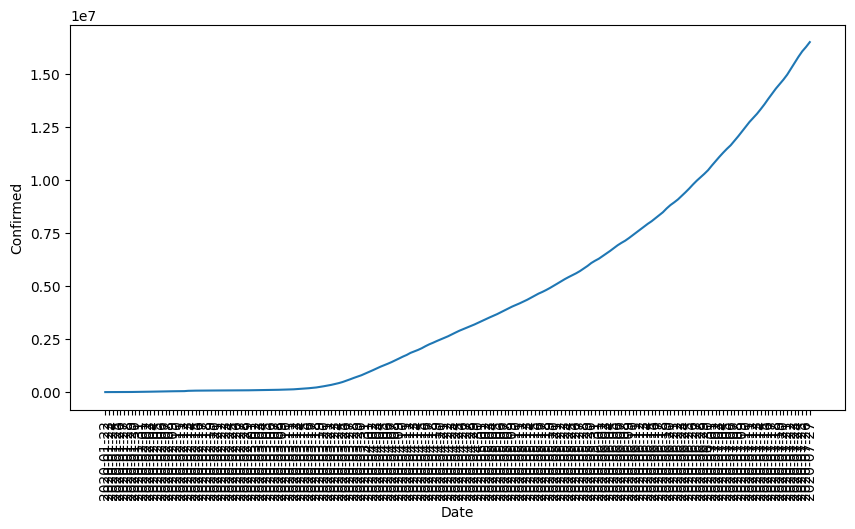

In [ ]:
# Visualization for confirmed cases
plt.figure(figsize=(10,5))
sns.lineplot(x="Date",y="Confirmed",data=confirmed)
plt.xticks(rotation=90)
plt.show()

In [ ]:
# Top 10 countries with Highest recovered cases

top10_recovered = df.groupby(by='country')['Recovered'].sum().sort_values(ascending=False).reset_index().head(10)
top10_recovered

,country,Recovered
0,US,56353416
1,Brazil,54492873
2,Russia,25120448
3,India,23783720
4,Germany,17107839
5,Italy,15673910
6,Iran,15200895
7,Spain,15093583
8,Turkey,13345389
9,Chile,13292593


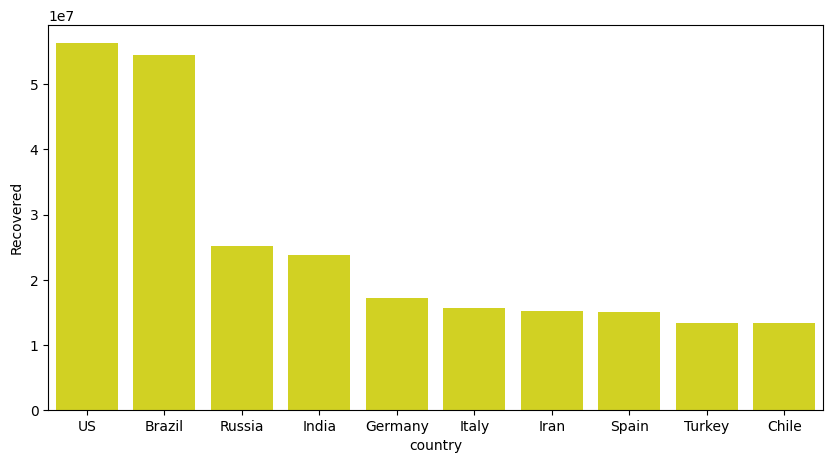

In [ ]:
plt.figure(figsize=(10,5))
sns.barplot(x="country",y="Recovered",data=top10_recovered,color="#EEEE06")
plt.show()

In [ ]:
# Top 10 countries with Active Cases

top10_active = df.groupby(by="country")["Active"].sum().sort_values(ascending=False).reset_index().head(10)
top10_active

,country,Active
0,US,156981121
1,Brazil,31094060
2,United Kingdom,22624595
3,Russia,19668578
4,India,15987913
5,France,10980287
6,Spain,9277432
7,Canada,8656985
8,Peru,7748957
9,Italy,7363518


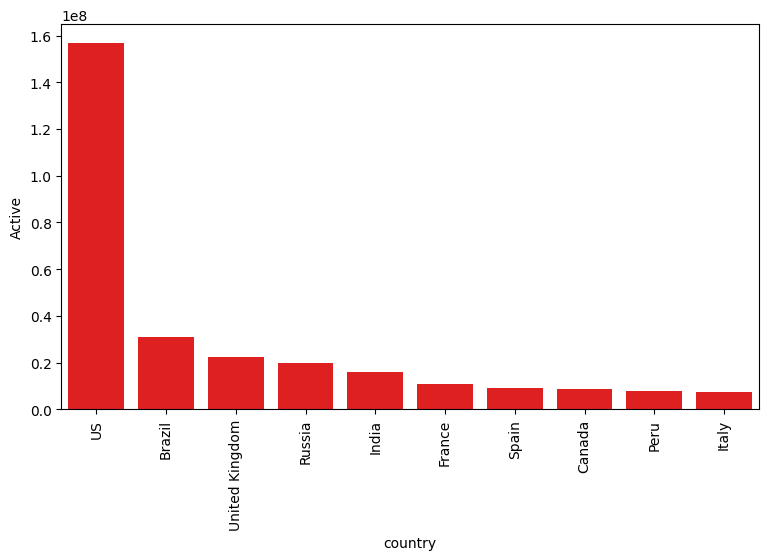

In [ ]:
plt.figure(figsize=(9,5))
sns.barplot(x="country",y="Active",data=top10_active,color="red")
plt.xticks(rotation=90) #rotates xlables downwards
plt.show()

In [ ]:
# Top 10 countries with more Death cases

top10_deaths = df.groupby(by="country")["Deaths"].sum().sort_values(ascending=False).reset_index().head(10)
top10_deaths

,country,Deaths
0,US,11011411
1,United Kingdom,3997775
2,Brazil,3938034
3,Italy,3707717
4,France,3048524
5,Spain,3033030
6,Mexico,1728277
7,India,1111831
8,Iran,1024136
9,Belgium,963679


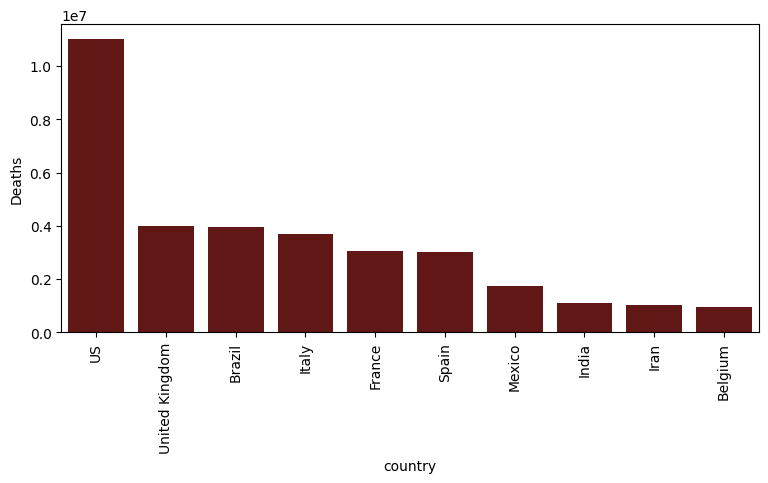

In [ ]:
plt.figure(figsize=(9,4))
sns.barplot(x="country",y="Deaths",data=top10_deaths,color="#6E0B0B")
plt.xticks(rotation=90)
plt.show()

# For India

In [ ]:
India = df[df["country"]=="India"]
India

,State,country,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
129,NaN,India,20.593684,78.96288,2020-01-22,0,0,0,0,South-East Asia
390,NaN,India,20.593684,78.96288,2020-01-23,0,0,0,0,South-East Asia
651,NaN,India,20.593684,78.96288,2020-01-24,0,0,0,0,South-East Asia
912,NaN,India,20.593684,78.96288,2020-01-25,0,0,0,0,South-East Asia
1173,NaN,India,20.593684,78.96288,2020-01-26,0,0,0,0,South-East Asia
...,...,...,...,...,...,...,...,...,...,...
47892,NaN,India,20.593684,78.96288,2020-07-23,1288108,30601,817209,440298,South-East Asia
48153,NaN,India,20.593684,78.96288,2020-07-24,1337024,31358,849432,456234,South-East Asia
48414,NaN,India,20.593684,78.96288,2020-07-25,1385635,32060,885573,468002,South-East Asia
48675,NaN,India,20.593684,78.96288,2020-07-26,1435616,32771,917568,485277,South-East Asia


In [ ]:
ConfirmedCasesInIndia_byDate = India.groupby(by="Date")["Confirmed"].sum().reset_index()
ConfirmedCasesInIndia_byDate

,Date,Confirmed
0,2020-01-22,0
1,2020-01-23,0
2,2020-01-24,0
3,2020-01-25,0
4,2020-01-26,0
...,...,...
183,2020-07-23,1288108
184,2020-07-24,1337024
185,2020-07-25,1385635
186,2020-07-26,1435616


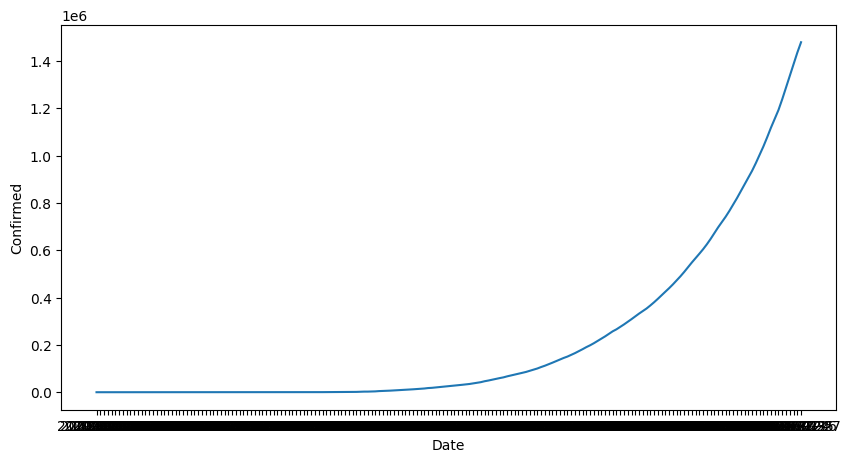

In [ ]:
plt.figure(figsize=(10,5))
sns.lineplot(x="Date",y="Confirmed",data = ConfirmedCasesInIndia_byDate)
#plt.xticks(rotation=90)
plt.show()

# Visualization using Plotly

About plotly: https://plotly.com/python/choropleth-maps/

In [ ]:
import plotly
import plotly.express as px

In [ ]:
df.columns

Index(['State', 'country', 'Lat', 'Long', 'Date', 'Confirmed', 'Deaths',
       'Recovered', 'Active', 'WHO Region'],
      dtype='object')

In [ ]:
world = df.groupby(by="country")[['Confirmed','Deaths','Recovered','Active']].sum().reset_index()
world

,country,Confirmed,Deaths,Recovered,Active
0,Afghanistan,1936390,49098,798240,1089052
1,Albania,196702,5708,118877,72117
2,Algeria,1179755,77972,755897,345886
3,Andorra,94404,5423,69074,19907
4,Angola,22662,1078,6573,15011
...,...,...,...,...,...
182,West Bank and Gaza,233461,1370,61124,170967
183,Western Sahara,901,63,648,190
184,Yemen,67180,17707,23779,25694
185,Zambia,129421,2643,83611,43167


In [ ]:
#To know more about plotly visualization and its features visit the above link

figure = px.choropleth(world,locations='country',
                       locationmode = 'country names',
                       color='Deaths', #Confirmed,Recovered,Active,Deaths
                       hover_name='country',range_color=[1,20000],
                       color_continuous_scale='Viridis',
                       title='Countries with - Cases')
figure.show()

# **Model Building**

Prophet is a forecasting library introduced by Facebook (Meta). It’s designed to make time series forecasting.
You use it when you want to predict future values like:

Sales,
Stock prices,
Temperature,
Website traffic,
Electricity usage,
Trend (increasing or decreasing)


In [ ]:
!pip install --upgrade prophet pystan cmdstanpy

In [ ]:
df = pd.read_csv('/content/Covid_19_Clean_Complete.csv',parse_dates=['Date'])
#our date col is in obj dtype, so we can covert into DATE dtype while loading the df itself or
#pd.to_datetime()

In [ ]:
df.dtypes

,0
Province/State,object
Country/Region,object
Lat,float64
Long,float64
Date,datetime64[ns]
Confirmed,int64
Deaths,int64
Recovered,int64
Active,int64
WHO Region,object


In [ ]:
confirmed = df.groupby(by="Date")["Confirmed"].sum().reset_index()
confirmed

,Date,Confirmed
0,2020-01-22,555
1,2020-01-23,654
2,2020-01-24,941
3,2020-01-25,1434
4,2020-01-26,2118
...,...,...
183,2020-07-23,15510481
184,2020-07-24,15791645
185,2020-07-25,16047190
186,2020-07-26,16251796


In [ ]:
recovered = df.groupby(by="Date")['Recovered'].sum().reset_index()
recovered

,Date,Recovered
0,2020-01-22,28
1,2020-01-23,30
2,2020-01-24,36
3,2020-01-25,39
4,2020-01-26,52
...,...,...
183,2020-07-23,8710969
184,2020-07-24,8939705
185,2020-07-25,9158743
186,2020-07-26,9293464


In [ ]:
active = df.groupby(by="Date")["Active"].sum().reset_index()
active

,Date,Active
0,2020-01-22,510
1,2020-01-23,606
2,2020-01-24,879
3,2020-01-25,1353
4,2020-01-26,2010
...,...,...
183,2020-07-23,6166006
184,2020-07-24,6212290
185,2020-07-25,6243930
186,2020-07-26,6309711


In [ ]:
# I wish to forcast the number of Confirmed cases (We can predict deaths and others also..)
# We aim to build a predictive model for future confirmed COVID-19 cases.

In [ ]:
confirmed.head(2)

,Date,Confirmed
0,2020-01-22,555
1,2020-01-23,654


In [ ]:
# I will rename col names, so it would be easier to understand the output of Prophet model

confirmed.columns = ["ds","y"]  #ds-dates, y-confirmed(we have to predict)

In [ ]:
confirmed

,ds,y
0,2020-01-22,555
1,2020-01-23,654
2,2020-01-24,941
3,2020-01-25,1434
4,2020-01-26,2118
...,...,...
183,2020-07-23,15510481
184,2020-07-24,15791645
185,2020-07-25,16047190
186,2020-07-26,16251796


In [ ]:
from prophet import Prophet
m = Prophet()

In normal machine-learning models (like Linear Regression, Logistic Regression, Random Forest), we split the data randomly into train and test because:

Each row is independent

The order of rows doesn’t matter

Random shuffling does not break the model

**But time-series is different**

⭐**Time-Series Depends on Time Order**

Today’s value depends on yesterday’s value.
Tomorrow’s value depends on today’s value.

This means:

Past → Present → Future

If we randomly split the data, the model might see:

Training data from 2023

Test data from 2021

Then training data again from 2022

This completely destroys the time-based pattern, So it should be in sorted order

In [ ]:
m.fit(confirmed)

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [ ]:
# Forcasting for next few dates

In [ ]:
# We have dates(cases) till 2020-07-27 in our data

# Prophet only knows the dates present in the original dataframe (df).
# So we have to add few more dates in our df to predict
#   → These dates are required because Prophet predicts on these dates
#   → Without future dates, Prophet cannot forecast anything beyond the existing data.

In [ ]:
future = m.make_future_dataframe(periods=7)
future.tail(20)

,ds
175,2020-07-15
176,2020-07-16
177,2020-07-17
178,2020-07-18
179,2020-07-19
180,2020-07-20
181,2020-07-21
182,2020-07-22
183,2020-07-23
184,2020-07-24


In [ ]:
forecast = m.predict(future)

In [ ]:
forecast

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2020-01-22,-9.613288e+03,-1.280227e+05,8.402217e+04,-9.613288e+03,-9.613288e+03,-11063.558307,-11063.558307,-11063.558307,-11063.558307,-11063.558307,-11063.558307,0.0,0.0,0.0,-2.067685e+04
1,2020-01-23,-6.933409e+03,-1.191347e+05,9.130255e+04,-6.933409e+03,-6.933409e+03,-1117.543863,-1117.543863,-1117.543863,-1117.543863,-1117.543863,-1117.543863,0.0,0.0,0.0,-8.050953e+03
2,2020-01-24,-4.253530e+03,-8.930780e+04,1.087195e+05,-4.253530e+03,-4.253530e+03,10080.978737,10080.978737,10080.978737,10080.978737,10080.978737,10080.978737,0.0,0.0,0.0,5.827449e+03
3,2020-01-25,-1.573651e+03,-9.504818e+04,1.118674e+05,-1.573651e+03,-1.573651e+03,13750.326871,13750.326871,13750.326871,13750.326871,13750.326871,13750.326871,0.0,0.0,0.0,1.217668e+04
4,2020-01-26,1.106228e+03,-1.012154e+05,1.090456e+05,1.106228e+03,1.106228e+03,7298.791978,7298.791978,7298.791978,7298.791978,7298.791978,7298.791978,0.0,0.0,0.0,8.405020e+03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
190,2020-07-30,1.674503e+07,1.663484e+07,1.684184e+07,1.674073e+07,1.675050e+07,-1117.543863,-1117.543863,-1117.543863,-1117.543863,-1117.543863,-1117.543863,0.0,0.0,0.0,1.674392e+07
191,2020-07-31,1.694902e+07,1.685396e+07,1.706723e+07,1.693960e+07,1.695996e+07,10080.978737,10080.978737,10080.978737,10080.978737,10080.978737,10080.978737,0.0,0.0,0.0,1.695911e+07
192,2020-08-01,1.715301e+07,1.705870e+07,1.728657e+07,1.713676e+07,1.717095e+07,13750.326871,13750.326871,13750.326871,13750.326871,13750.326871,13750.326871,0.0,0.0,0.0,1.716677e+07
193,2020-08-02,1.735701e+07,1.724622e+07,1.748141e+07,1.733192e+07,1.738293e+07,7298.791978,7298.791978,7298.791978,7298.791978,7298.791978,7298.791978,0.0,0.0,0.0,1.736430e+07


In [ ]:
1.356800e+07
# Move decimal 7 places to the right (Add zeros as needed)
#     → It means 10 power'7 (e+07 → multiply the value with 10 power'7)

1.356800e-07
# Move decimal 7 places to the left
#     → It means 10 power'-7 (e-07 → Divide the value by 10 power'7)

1.3568e-07

In [ ]:
#forecast[['ds','yhat','yhat_upper','yhat_lower']]

'''
ds:
This column contains the dates for which the predictions have been made. It stands for "date stamp."

yhat:
This is the predicted value (forecast) for the given date in the ds column. It represents the model's best estimate for that point in time.

yhat_upper:
This column represents the upper bound of the predicted value, which indicates the higher end of the confidence interval.
It suggests that the actual value is unlikely to exceed this amount, giving you an idea of the prediction's uncertainty.

yhat_lower:
This column represents the lower bound of the predicted value, indicating the lower end of the confidence interval. It suggests that the actual value is unlikely to be lower than this amount.
'''

'\nds:\nThis column contains the dates for which the predictions have been made. It stands for "date stamp."\n\nyhat:\nThis is the predicted value (forecast) for the given date in the ds column. It represents the model\'s best estimate for that point in time.\n\nyhat_upper:\nThis column represents the upper bound of the predicted value, which indicates the higher end of the confidence interval.\nIt suggests that the actual value is unlikely to exceed this amount, giving you an idea of the prediction\'s uncertainty.\n\nyhat_lower:\nThis column represents the lower bound of the predicted value, indicating the lower end of the confidence interval. It suggests that the actual value is unlikely to be lower than this amount.\n'

In [ ]:
forecast.tail(9)

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
186,2020-07-26,1.592907e+07,1.583101e+07,1.603983e+07,1.592907e+07,1.592907e+07,7298.791978,7298.791978,7298.791978,7298.791978,7298.791978,7298.791978,0.0,0.0,0.0,1.593637e+07
187,2020-07-27,1.613306e+07,1.603151e+07,1.623858e+07,1.613306e+07,1.613306e+07,-2102.755455,-2102.755455,-2102.755455,-2102.755455,-2102.755455,-2102.755455,0.0,0.0,0.0,1.613096e+07
188,2020-07-28,1.633705e+07,1.621565e+07,1.643104e+07,1.633705e+07,1.633705e+07,-16846.239961,-16846.239961,-16846.239961,-16846.239961,-16846.239961,-16846.239961,0.0,0.0,0.0,1.632021e+07
189,2020-07-29,1.654104e+07,1.642370e+07,1.663836e+07,1.654032e+07,1.654243e+07,-11063.558307,-11063.558307,-11063.558307,-11063.558307,-11063.558307,-11063.558307,0.0,0.0,0.0,1.652998e+07
190,2020-07-30,1.674503e+07,1.663484e+07,1.684184e+07,1.674073e+07,1.675050e+07,-1117.543863,-1117.543863,-1117.543863,-1117.543863,-1117.543863,-1117.543863,0.0,0.0,0.0,1.674392e+07
191,2020-07-31,1.694902e+07,1.685396e+07,1.706723e+07,1.693960e+07,1.695996e+07,10080.978737,10080.978737,10080.978737,10080.978737,10080.978737,10080.978737,0.0,0.0,0.0,1.695911e+07
192,2020-08-01,1.715301e+07,1.705870e+07,1.728657e+07,1.713676e+07,1.717095e+07,13750.326871,13750.326871,13750.326871,13750.326871,13750.326871,13750.326871,0.0,0.0,0.0,1.716677e+07
193,2020-08-02,1.735701e+07,1.724622e+07,1.748141e+07,1.733192e+07,1.738293e+07,7298.791978,7298.791978,7298.791978,7298.791978,7298.791978,7298.791978,0.0,0.0,0.0,1.736430e+07
194,2020-08-03,1.756100e+07,1.744130e+07,1.767707e+07,1.752515e+07,1.759676e+07,-2102.755455,-2102.755455,-2102.755455,-2102.755455,-2102.755455,-2102.755455,0.0,0.0,0.0,1.755889e+07


In [ ]:
#1.755889e+07 -- 17,558,890 → Number of Confirmed cases on 3rd Aug i.e., 7th day after 27th July

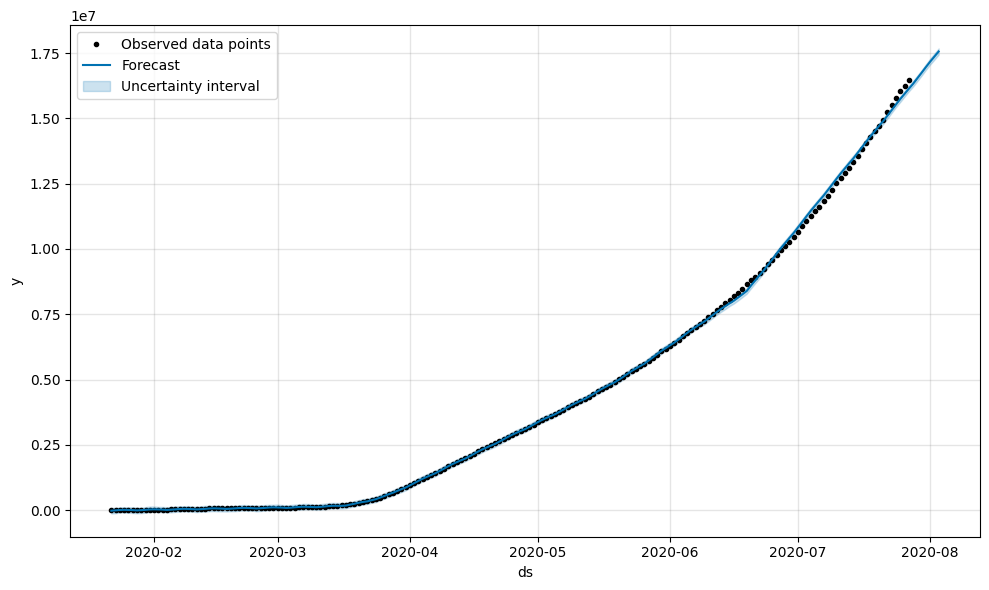

In [ ]:
import matplotlib.pyplot as plt

m.plot(forecast)
plt.legend()
plt.show()

*That's it! Unlike traditional time-series models such as ARIMA or SARIMA, Prophet makes the entire forecasting process much simpler. In normal time-series modelling, we usually have to perform many extra steps — checking for stationarity, converting data using differencing, removing trends manually, tuning seasonal parameters, and carefully transforming the data until the model becomes stable.

With Prophet, we don’t need to do most of those operations. The library automatically handles trend detection, seasonality, changepoints, and missing dates. As long as our data has a proper date column (ds) and a target value (y), Prophet can fit the model and produce reliable forecasts with minimal preprocessing. This makes it especially useful for datasets like COVID-19 confirmed cases, where trends can shift quickly and patterns are not always consistent.

Overall, Prophet provides a more flexible, beginner-friendly, and efficient approach to time-series forecasting compared to traditional statistical models, while still giving strong and interpretable results.*

⭐This forecasting task highlights an important difference between regression models and time-series models. Regression algorithms treat data as independent observations, so the order of rows does not matter. However, in time-series forecasting, the sequence of dates is critical because each value depends on previous values. Prophet understands this dependency and builds the forecast by learning patterns over time, which regression models cannot do. As a result, Prophet gives more meaningful predictions for future confirmed cases compared to standard regression methods.


                                                                        ----

In [ ]:
# It is very simple to build a model.
# If it is looking complex in the above colab which included texts & explainations, will build a model to predict "Deaths" for next 10 days without any explainations 👍😅

In [ ]:
df.head(10)

,Province/State,Country/Region,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
0,NaN,Afghanistan,33.93911,67.709953,2020-01-22,0,0,0,0,Eastern Mediterranean
1,NaN,Albania,41.15330,20.168300,2020-01-22,0,0,0,0,Europe
2,NaN,Algeria,28.03390,1.659600,2020-01-22,0,0,0,0,Africa
3,NaN,Andorra,42.50630,1.521800,2020-01-22,0,0,0,0,Europe
4,NaN,Angola,-11.20270,17.873900,2020-01-22,0,0,0,0,Africa
5,NaN,Antigua and Barbuda,17.06080,-61.796400,2020-01-22,0,0,0,0,Americas
6,NaN,Argentina,-38.41610,-63.616700,2020-01-22,0,0,0,0,Americas
7,NaN,Armenia,40.06910,45.038200,2020-01-22,0,0,0,0,Europe
8,Australian Capital Territory,Australia,-35.47350,149.012400,2020-01-22,0,0,0,0,Western Pacific
9,New South Wales,Australia,-33.86880,151.209300,2020-01-22,0,0,0,0,Western Pacific


In [ ]:
df.dtypes #if date is obj dtype convert to DATE dtype

,0
Province/State,object
Country/Region,object
Lat,float64
Long,float64
Date,datetime64[ns]
Confirmed,int64
Deaths,int64
Recovered,int64
Active,int64
WHO Region,object


In [ ]:
df["Date"] = pd.to_datetime(df['Date'])

In [ ]:
!pip install --upgrade prophet pystan cmdstanpy

In [ ]:
#Number of deaths on each date
deaths = df.groupby(by="Date")["Deaths"].sum().reset_index()
deaths

,Date,Deaths
0,2020-01-22,17
1,2020-01-23,18
2,2020-01-24,26
3,2020-01-25,42
4,2020-01-26,56
...,...,...
183,2020-07-23,633506
184,2020-07-24,639650
185,2020-07-25,644517
186,2020-07-26,648621


In [ ]:
# IMPORTANT:
# Prophet ALWAYS needs the column names 'ds' and 'y'.
# It will not accept any other names.

# ds = datestamp (the timeline of the series)
# y  = observed values (the numbers we want to predict)

# Without this renaming step, Prophet will raise:
# ValueError: Dataframe must have columns "ds" and "y"

In [ ]:
# Prophet requires the dataframe to have exactly two columns:
#   ds --> the date column
#   y  --> the numeric values we want to forecast
#
# Prophet's internal functions look specifically for these names.
# Any other column names (like 'Date', 'Confirmed', 'Cases', etc.)
# will cause an error.

In [ ]:
deaths.columns=['ds','y']
deaths

,ds,y
0,2020-01-22,17
1,2020-01-23,18
2,2020-01-24,26
3,2020-01-25,42
4,2020-01-26,56
...,...,...
183,2020-07-23,633506
184,2020-07-24,639650
185,2020-07-25,644517
186,2020-07-26,648621


In [ ]:
from prophet import Prophet
model = Prophet()

In [ ]:
model.fit(deaths)

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [ ]:
#Predict deaths for next 10 dates

In [ ]:
next10 = model.make_future_dataframe(periods=10)
next10.tail(15)

,ds
183,2020-07-23
184,2020-07-24
185,2020-07-25
186,2020-07-26
187,2020-07-27
188,2020-07-28
189,2020-07-29
190,2020-07-30
191,2020-07-31
192,2020-08-01


In [ ]:
forecast = model.predict(next10)

In [ ]:
forecast

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2020-01-22,-522.113185,-2456.679696,1253.538024,-522.113185,-522.113185,-191.187755,-191.187755,-191.187755,-191.187755,-191.187755,-191.187755,0.0,0.0,0.0,-713.300939
1,2020-01-23,-432.419342,-1960.831893,1847.940414,-432.419342,-432.419342,388.672065,388.672065,388.672065,388.672065,388.672065,388.672065,0.0,0.0,0.0,-43.747277
2,2020-01-24,-342.725499,-1426.967039,2492.776782,-342.725499,-342.725499,874.264079,874.264079,874.264079,874.264079,874.264079,874.264079,0.0,0.0,0.0,531.538580
3,2020-01-25,-253.031656,-1434.775289,2304.818061,-253.031656,-253.031656,726.889465,726.889465,726.889465,726.889465,726.889465,726.889465,0.0,0.0,0.0,473.857809
4,2020-01-26,-163.337813,-2319.623113,1551.118442,-163.337813,-163.337813,-165.600459,-165.600459,-165.600459,-165.600459,-165.600459,-165.600459,0.0,0.0,0.0,-328.938272
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
193,2020-08-02,678190.961084,675316.391778,680431.644291,676740.121359,679571.765763,-165.600459,-165.600459,-165.600459,-165.600459,-165.600459,-165.600459,0.0,0.0,0.0,678025.360624
194,2020-08-03,683220.370024,679418.461955,685195.015909,681243.104970,685194.772842,-904.694278,-904.694278,-904.694278,-904.694278,-904.694278,-904.694278,0.0,0.0,0.0,682315.675746
195,2020-08-04,688249.778964,684352.756009,690480.670300,685755.439211,690762.742772,-728.343117,-728.343117,-728.343117,-728.343117,-728.343117,-728.343117,0.0,0.0,0.0,687521.435847
196,2020-08-05,693279.187904,689246.255003,696538.415774,690283.442340,696446.355357,-191.187755,-191.187755,-191.187755,-191.187755,-191.187755,-191.187755,0.0,0.0,0.0,693088.000150


In [ ]:
#yhat_upper - maximum predicted value
#yhat_lower - minimum predicted value
#yhat       - Best estimated value

#If we want, we can create dataframe seperately to see predicted deaths in each date

In [ ]:
exact = pd.DataFrame({"ds":forecast['ds'], "yhat(No of Deaths)":forecast['yhat']})
exact.tail(15) #smthng wrong wait

,ds,yhat(No of Deaths)
183,2020-07-23,628285.543747
184,2020-07-24,633800.544702
185,2020-07-25,638682.579028
186,2020-07-26,642819.498044
187,2020-07-27,647109.813166
188,2020-07-28,652315.573266
189,2020-07-29,657882.137569
190,2020-07-30,663491.406328
191,2020-07-31,669006.407283
192,2020-08-01,673888.441609


In [ ]:
df.tail(5)

,Province/State,Country/Region,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
49063,NaN,Sao Tome and Principe,0.186400,6.613100,2020-07-27,865,14,734,117,Africa
49064,NaN,Yemen,15.552727,48.516388,2020-07-27,1691,483,833,375,Eastern Mediterranean
49065,NaN,Comoros,-11.645500,43.333300,2020-07-27,354,7,328,19,Africa
49066,NaN,Tajikistan,38.861000,71.276100,2020-07-27,7235,60,6028,1147,Europe
49067,NaN,Lesotho,-29.610000,28.233600,2020-07-27,505,12,128,365,Africa


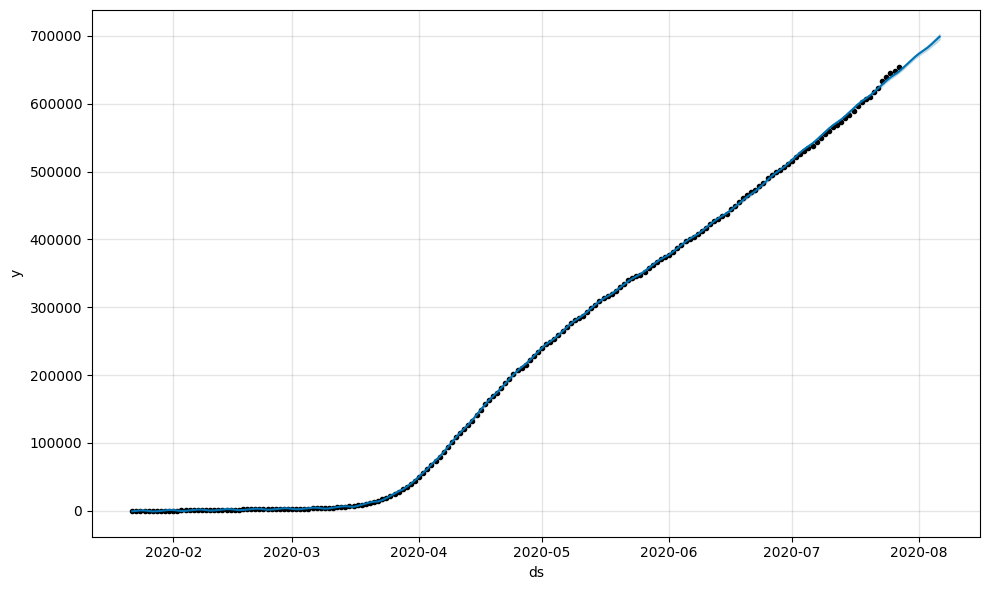

In [ ]:
import matplotlib.pyplot as plt

model.plot(forecast)
plt.show()